# Sparse Cell Channel — Metrics Over Time (GM vs PP v2)

Comparison of GM (getMotion, zRatio=10) and PP v2 (Phase Persist, fixed).
Metrics computed on **foreground pixels only** (k=2), normalized to [0, 255].
Centroid detection: mean + 2σ within foreground mask, radius=5px.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

GM_CSV  = Path("/mnt/data21T_2/cyf/f260517/GM_mapped_v2_layer3/metrics.csv")
PP_CSV  = Path("/mnt/data21T_2/cyf/f260517/PP_baseline_l3/metrics.csv")
OUT_DIR = Path("/home/cyf/wbi/Virginia/code_for_paper/Fig3")

df_gm = pd.read_csv(GM_CSV)
df_pp = pd.read_csv(PP_CSV)
frames = df_gm["frame"].values

def smooth(series, window=5):
    return series.rolling(window, center=True, min_periods=1).mean()

c_gm = "#4DAF4A"
c_pp = "#2166AC"

print(f"GM:  {len(df_gm)} frames  |  PP v2: {len(df_pp)} frames")
print(f"Columns: {list(df_gm.columns)}")

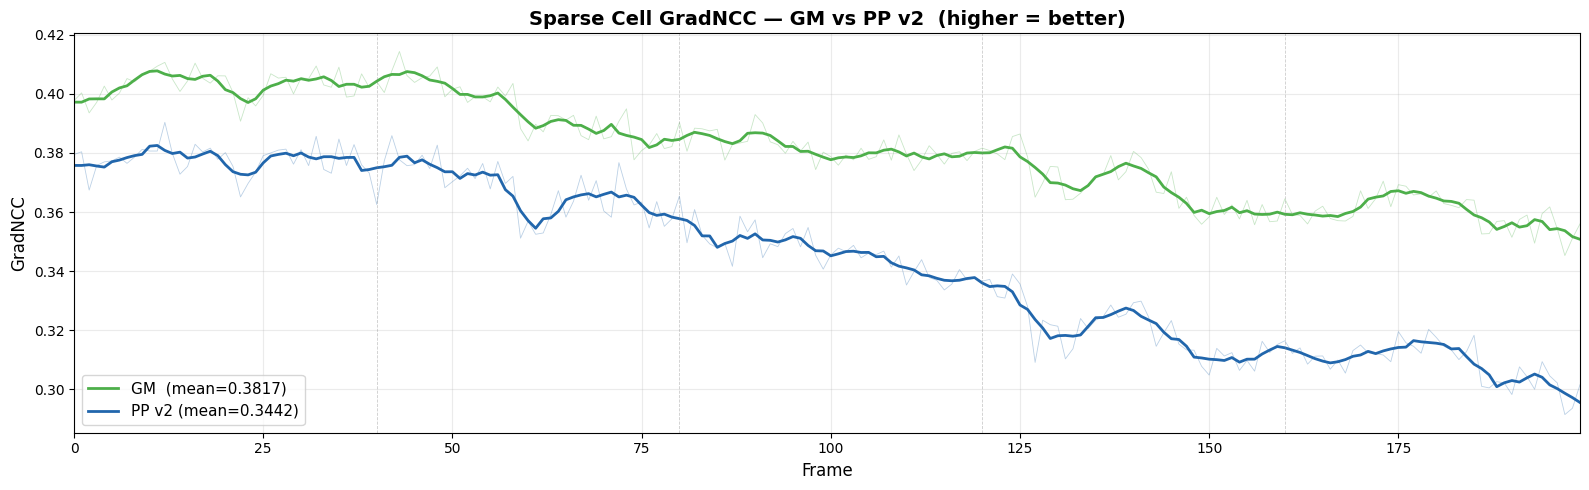

Saved to sparse_GradNCC_GM_vs_PPv2.png


In [2]:
# ================================================================
# Figure 1: Sparse GradNCC — GM vs PP v2
# ================================================================
WINDOW = 5

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(frames, df_gm["sp_GradNCC"], color=c_gm, lw=0.6, alpha=0.3)
ax.plot(frames, df_pp["sp_GradNCC"], color=c_pp, lw=0.6, alpha=0.3)
ax.plot(frames, smooth(df_gm["sp_GradNCC"], WINDOW), color=c_gm, lw=2.0, label=f"GM  (mean={df_gm['sp_GradNCC'].mean():.4f})")
ax.plot(frames, smooth(df_pp["sp_GradNCC"], WINDOW), color=c_pp, lw=2.0, label=f"PP v2 (mean={df_pp['sp_GradNCC'].mean():.4f})")

for rf in [40, 80, 120, 160]:
    ax.axvline(x=rf, color="gray", lw=0.6, ls="--", alpha=0.4)

ax.set_ylabel("GradNCC", fontsize=12)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Sparse Cell GradNCC — GM vs PP v2  (higher = better)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 199)

fig.tight_layout()
fig.savefig(str(OUT_DIR / "sparse_GradNCC_GM_vs_PPv2.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to sparse_GradNCC_GM_vs_PPv2.png")

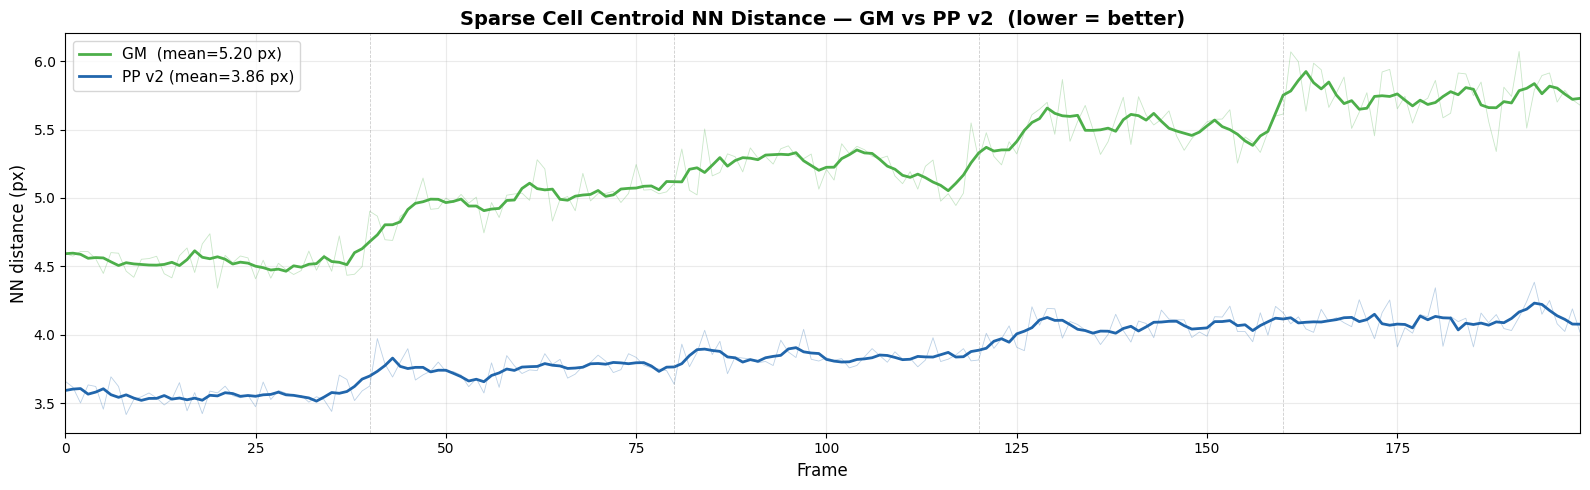

Saved to sparse_NN_GM_vs_PPv2.png


In [3]:
# ================================================================
# Figure 2: Sparse Centroid NN Distance — GM vs PP v2
# ================================================================
WINDOW = 5

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(frames, df_gm["sp_NN"], color=c_gm, lw=0.6, alpha=0.3)
ax.plot(frames, df_pp["sp_NN"], color=c_pp, lw=0.6, alpha=0.3)
ax.plot(frames, smooth(df_gm["sp_NN"], WINDOW), color=c_gm, lw=2.0, label=f"GM  (mean={df_gm['sp_NN'].mean():.2f} px)")
ax.plot(frames, smooth(df_pp["sp_NN"], WINDOW), color=c_pp, lw=2.0, label=f"PP v2 (mean={df_pp['sp_NN'].mean():.2f} px)")

for rf in [40, 80, 120, 160]:
    ax.axvline(x=rf, color="gray", lw=0.6, ls="--", alpha=0.4)

ax.set_ylabel("NN distance (px)", fontsize=12)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Sparse Cell Centroid NN Distance — GM vs PP v2  (lower = better)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 199)

fig.tight_layout()
fig.savefig(str(OUT_DIR / "sparse_NN_GM_vs_PPv2.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to sparse_NN_GM_vs_PPv2.png")

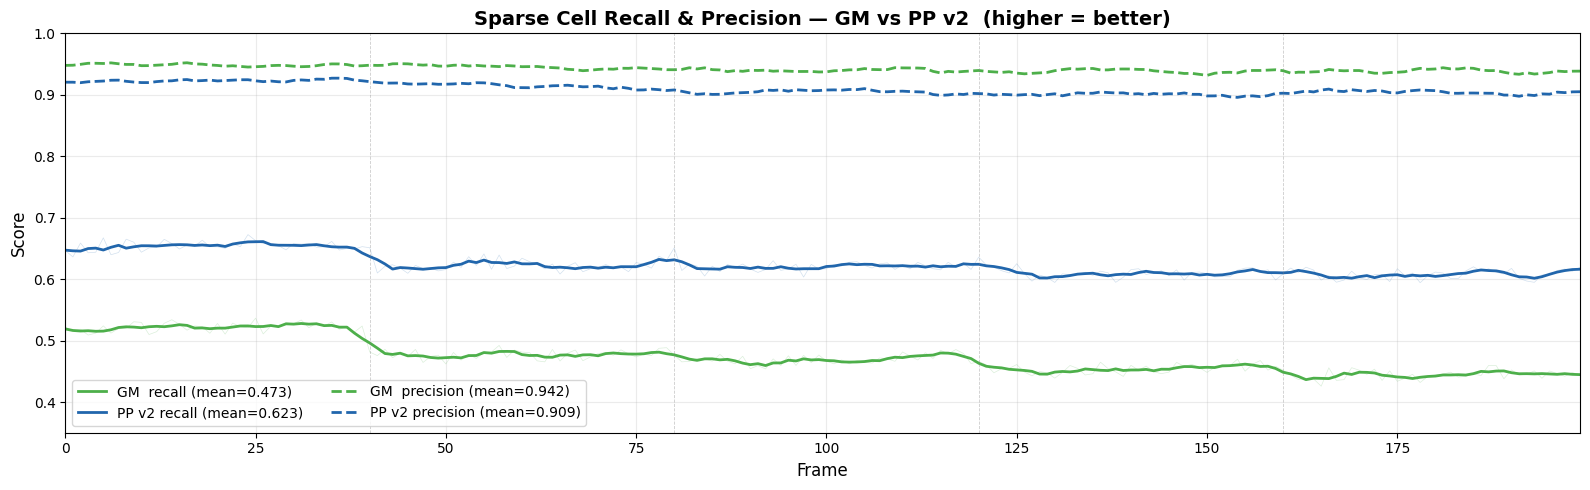

Saved to sparse_RecallPrecision_GM_vs_PPv2.png


In [4]:
# ================================================================
# Figure 3: Sparse Recall & Precision — GM vs PP v2
# ================================================================
WINDOW = 5

fig, ax = plt.subplots(figsize=(16, 5))

# Recall (solid lines)
ax.plot(frames, df_gm["sp_recall"], color=c_gm, lw=0.5, alpha=0.2)
ax.plot(frames, df_pp["sp_recall"], color=c_pp, lw=0.5, alpha=0.2)
ax.plot(frames, smooth(df_gm["sp_recall"], WINDOW), color=c_gm, lw=2.0, label=f"GM  recall (mean={df_gm['sp_recall'].mean():.3f})")
ax.plot(frames, smooth(df_pp["sp_recall"], WINDOW), color=c_pp, lw=2.0, label=f"PP v2 recall (mean={df_pp['sp_recall'].mean():.3f})")

# Precision (dashed lines)
ax.plot(frames, smooth(df_gm["sp_precision"], WINDOW), color=c_gm, lw=2.0, ls="--", label=f"GM  precision (mean={df_gm['sp_precision'].mean():.3f})")
ax.plot(frames, smooth(df_pp["sp_precision"], WINDOW), color=c_pp, lw=2.0, ls="--", label=f"PP v2 precision (mean={df_pp['sp_precision'].mean():.3f})")

for rf in [40, 80, 120, 160]:
    ax.axvline(x=rf, color="gray", lw=0.6, ls="--", alpha=0.4)

ax.set_ylabel("Score", fontsize=12)
ax.set_xlabel("Frame", fontsize=12)
ax.set_title("Sparse Cell Recall & Precision — GM vs PP v2  (higher = better)", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="lower left", ncol=2)
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 199)
ax.set_ylim(0.35, 1.0)

fig.tight_layout()
fig.savefig(str(OUT_DIR / "sparse_RecallPrecision_GM_vs_PPv2.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to sparse_RecallPrecision_GM_vs_PPv2.png")